GPU detected: /physical_device:GPU:0

LOADING DATASET

Loading Normal...
  OK  100: 200 beats
  OK  101: 200 beats
  OK  103: 200 beats
  OK  105: 200 beats
  Total Normal: 800 beats from 4 records

Loading AF...
  OK  04015: 14 beats
  OK  04043: 150 beats
  OK  04048: 14 beats
  OK  04746: 10 beats
  OK  04908: 16 beats
  OK  05091: 16 beats
  Total AF: 220 beats from 6 records

Loading AFL...
  OK  202: 37 beats
  OK  207: 107 beats
  OK  217: 200 beats
  Total AFL: 344 beats from 3 records

Loading PVC...
  OK  106: 200 beats
  OK  119: 200 beats
  OK  200: 200 beats
  OK  208: 200 beats
  Total PVC: 800 beats from 4 records

DATASET SUMMARY
  Normal    : 800 beats
  AF        : 220 beats
  AFL       : 344 beats
  PVC       : 800 beats
  TOTAL     : 2164 beats


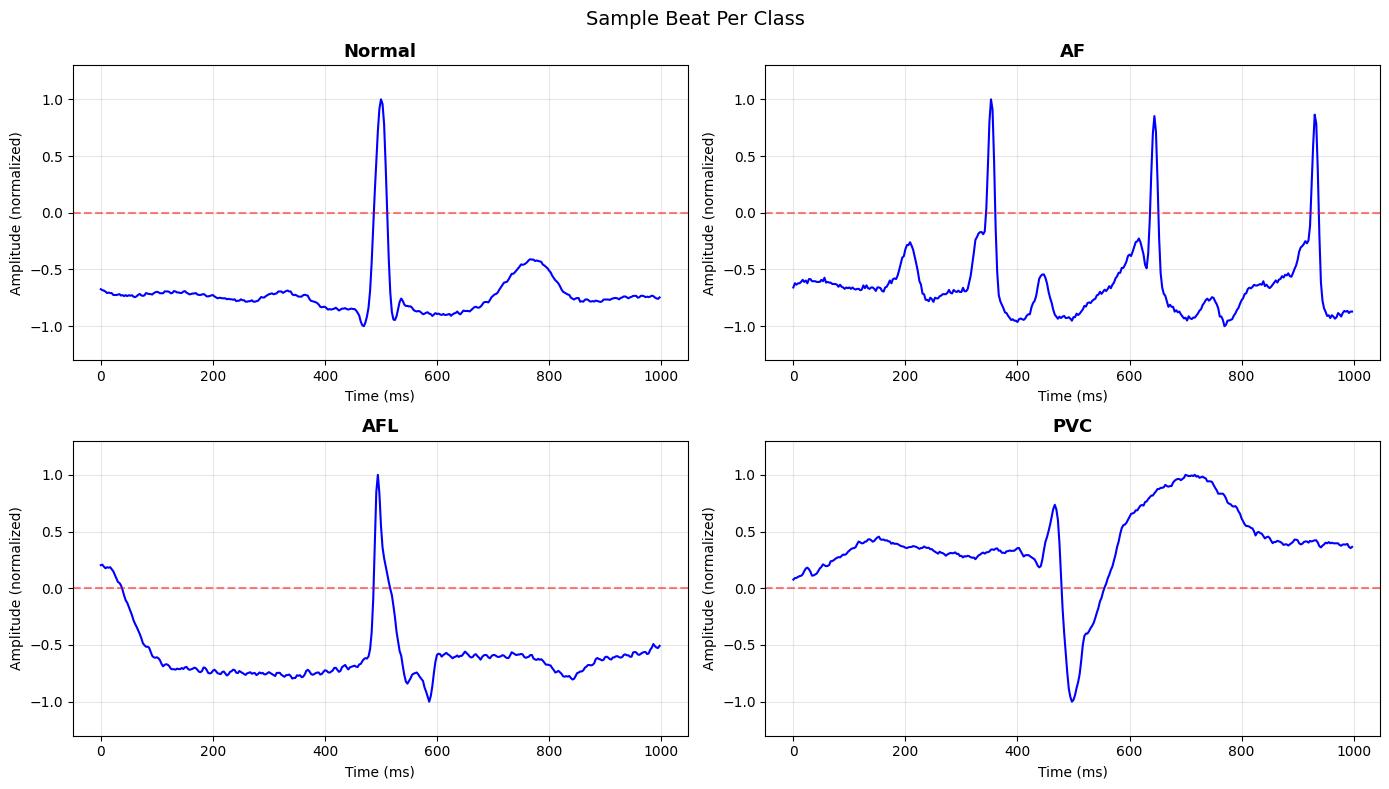


Train: 1731 | Test: 433

Balancing training data:
  Normal: 640 → 640
  AF: 176 → 640
  AFL: 275 → 640
  PVC: 640 → 640
Model: "ECG_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 360, 1)]          0         
                                                                 
 conv1d_12 (Conv1D)          (None, 360, 32)           256       
                                                                 
 batch_normalization_12 (Bat  (None, 360, 32)          128       
 chNormalization)                                                
                                                                 
 re_lu_12 (ReLU)             (None, 360, 32)           0         
                                                                 
 max_pooling1d_12 (MaxPoolin  (None, 180, 32)          0         
 g1D)                                                          

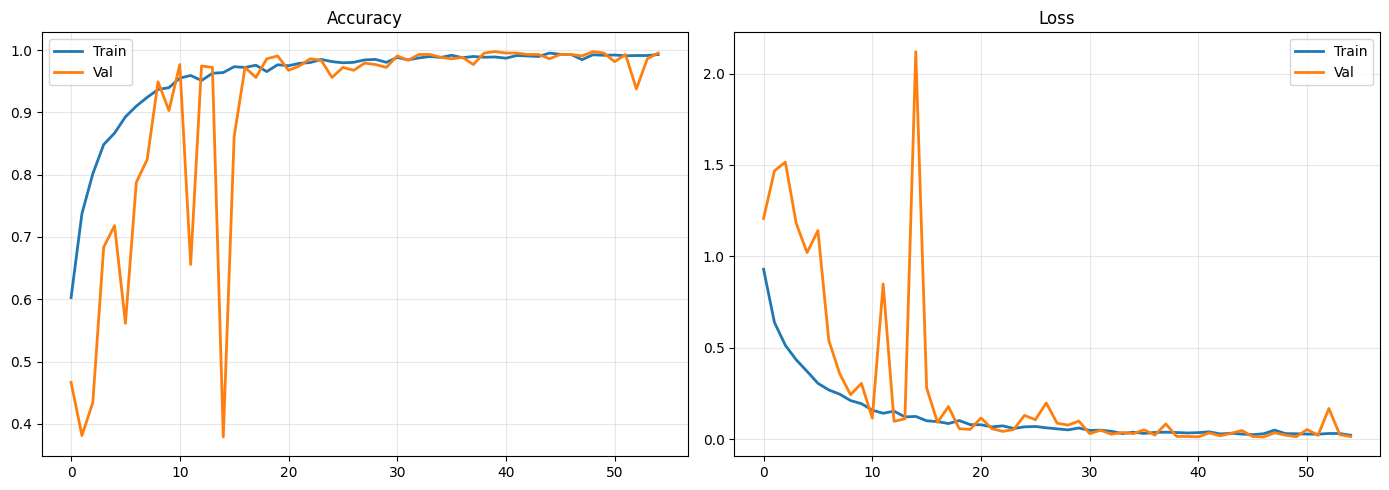


EVALUATION RESULTS
Test Accuracy: 99.77%
Test Loss:     0.0145

Classification Report:
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000       160
          AF     1.0000    0.9773    0.9885        44
         AFL     1.0000    1.0000    1.0000        69
         PVC     0.9938    1.0000    0.9969       160

    accuracy                         0.9977       433
   macro avg     0.9984    0.9943    0.9963       433
weighted avg     0.9977    0.9977    0.9977       433

Confusion Matrix:
[[160   0   0   0]
 [  0  43   0   1]
 [  0   0  69   0]
 [  0   0   0 160]]
Classes order: ['Normal', 'AF', 'AFL', 'PVC']

Per-Class Accuracy:
  Normal: 100.00%
  AF: 97.73%
  AFL: 100.00%
  PVC: 100.00%


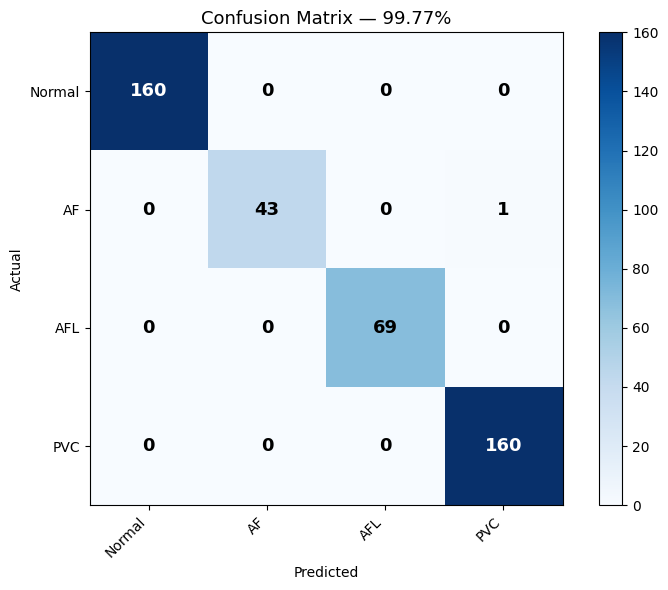


Converting to TFLite float32...


INFO:tensorflow:Assets written to: C:\Users\SHRAVAN\AppData\Local\Temp\tmp65ogn_9n\assets


INFO:tensorflow:Assets written to: C:\Users\SHRAVAN\AppData\Local\Temp\tmp65ogn_9n\assets


Converting to TFLite int8 quantized...


INFO:tensorflow:Assets written to: C:\Users\SHRAVAN\AppData\Local\Temp\tmpeh_wz73p\assets


INFO:tensorflow:Assets written to: C:\Users\SHRAVAN\AppData\Local\Temp\tmpeh_wz73p\assets



COMPLETE
  Accuracy:         99.77%
  Classes:          ['Normal', 'AF', 'AFL', 'PVC']
  Standard TFLite:  181.5 KB
  Quantized TFLite: 60.4 KB  ← ESP32
  C Header:         ecg_model.h
  Best model:       best_ecg_model.h5


In [9]:
# =============================================================
# ECG ARRHYTHMIA CLASSIFIER — COMPLETE ALL-IN-ONE
# 4 Classes: Normal | AF | Atrial Flutter | PVC
# Fixed: correct annotations, no data leakage, proper preprocessing
# =============================================================

import tensorflow as tf
import numpy as np
import wfdb
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy import signal as scipy_signal
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# =============================================================
# CONFIGURATION — CHANGE ONLY THIS SECTION IF NEEDED
# =============================================================

DATASET_PATH = r'C:\Users\SHRAVAN\Downloads'

# Reconstructed dictionary with all 4 classes
CLASS_CONFIG = {
    'Normal': {
        'records': ['100', '101', '103', '105'],
        'symbols': ['N'],
        'max_per_record': 200
    },
    'AF': {
        'records': ['04015', '04043', '04048', '04746', '04908', '05091'],
        'symbols': ['N', 'n', '+'],   # AF database symbols
        'max_per_record': 150
    },
    'AFL': {
        'records': ['202', '207', '217'],
        'symbols': ['F', 'f', 'A'],
        'max_per_record': 200
    },
    'PVC': {
        'records': ['106', '119', '200', '208'],
        'symbols': ['V'],
        'max_per_record': 200
    }
}

BEAT_WINDOW  = 180    # samples before and after R peak
INPUT_SIZE   = 360    # total beat length (BEAT_WINDOW * 2)
FS           = 360    # sampling frequency Hz
EPOCHS       = 80
BATCH_SIZE   = 32
TEST_SIZE    = 0.2
RANDOM_SEED  = 42

# =============================================================
# GPU SETUP
# =============================================================

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU detected: {gpus[0].name}')
else:
    print('No GPU found — using CPU')

# =============================================================
# PREPROCESSING FUNCTIONS
# =============================================================

def remove_baseline_wander(ecg_signal, fs=360):
    """High-pass filter at 0.5Hz to remove DC offset and baseline wander."""
    nyq    = fs / 2.0
    cutoff = 0.5 / nyq
    b, a   = scipy_signal.butter(2, cutoff, btype='high')
    return scipy_signal.filtfilt(b, a, ecg_signal)

def normalize_beat(beat):
    """Normalize a single beat to [-1, +1]."""
    min_val = np.min(beat)
    max_val = np.max(beat)
    if max_val - min_val < 1e-6:
        return np.zeros_like(beat)
    return (2.0 * (beat - min_val) / (max_val - min_val) - 1.0)

def extract_beat(ecg_signal, r_peak_pos, window=180):
    """Extract a single beat centered on R peak."""
    start = r_peak_pos - window
    end   = r_peak_pos + window
    if start < 0 or end > len(ecg_signal):
        return None
    beat = ecg_signal[start:end]
    if len(beat) != INPUT_SIZE:
        return None
    return beat

# =============================================================
# DATA LOADING
# =============================================================

def load_beats_for_class(class_name, config, dataset_path):
    beats = []
    records_loaded = 0
    original_dir = os.getcwd()
    
    # Ensure path exists before changing directory
    if not os.path.exists(dataset_path):
        print(f"Error: Path {dataset_path} does not exist.")
        return []

    os.chdir(dataset_path)
    print(f'\nLoading {class_name}...')

    for record_id in config['records']:
        if not os.path.exists(f'{record_id}.dat'):
            print(f'  SKIP {record_id} — file not found')
            continue
        try:
            record      = wfdb.rdrecord(record_id, channels=[0])
            annotations = wfdb.rdann(record_id, 'atr')
            ecg_signal  = record.p_signal.flatten()

            ecg_signal  = remove_baseline_wander(ecg_signal, fs=FS)

            beat_count = 0
            for pos, symbol in zip(annotations.sample, annotations.symbol):
                if symbol not in config['symbols']:
                    continue
                if beat_count >= config['max_per_record']:
                    break
                beat = extract_beat(ecg_signal, pos, BEAT_WINDOW)
                if beat is None:
                    continue
                beat = normalize_beat(beat)
                beats.append(beat.astype(np.float32))
                beat_count += 1

            if beat_count > 0:
                print(f'  OK  {record_id}: {beat_count} beats')
                records_loaded += 1
            else:
                print(f'  WARN {record_id}: 0 beats found for symbols {config["symbols"]}')

        except Exception as e:
            print(f'  ERROR {record_id}: {e}')
            continue

    os.chdir(original_dir)
    print(f'  Total {class_name}: {len(beats)} beats from {records_loaded} records')
    return beats

def load_all_classes():
    all_beats  = []
    all_labels = []
    class_list = list(CLASS_CONFIG.keys())

    print('\n' + '='*55)
    print('LOADING DATASET')
    print('='*55)

    for class_idx, class_name in enumerate(class_list):
        beats = load_beats_for_class(class_name, CLASS_CONFIG[class_name], DATASET_PATH)
        if len(beats) == 0:
            print(f'WARNING: No beats loaded for {class_name}')
            continue
        all_beats.extend(beats)
        all_labels.extend([class_idx] * len(beats))

    X = np.array(all_beats,  dtype=np.float32)
    y = np.array(all_labels, dtype=np.int32)

    print('\n' + '='*55)
    print('DATASET SUMMARY')
    print('='*55)
    for class_idx, class_name in enumerate(class_list):
        count = np.sum(y == class_idx)
        print(f'  {class_name:<10}: {count} beats')
    print(f'  {"TOTAL":<10}: {len(X)} beats')
    print('='*55)

    return X, y, class_list

# =============================================================
# AUGMENTATION
# =============================================================

def augment_beat(beat):
    aug = beat.copy()
    # Gaussian noise
    aug += np.random.normal(0, np.random.uniform(0.005, 0.02), aug.shape)
    # Amplitude scaling
    aug *= np.random.uniform(0.85, 1.15)
    # Time shift
    shift = np.random.randint(-5, 6)
    if shift != 0:
        aug = np.roll(aug, shift)
        if shift > 0:
            aug[:shift] = 0
        else:
            aug[shift:] = 0
    # Baseline wander
    t = np.arange(len(aug)) / FS
    aug += np.random.uniform(0.01, 0.05) * np.sin(2 * np.pi * np.random.uniform(0.1, 0.4) * t)
    return normalize_beat(aug).astype(np.float32)

def balance_and_augment(X_train, y_train, class_names):
    num_classes   = len(class_names)
    class_counts  = [np.sum(y_train == i) for i in range(num_classes)]
    target_count  = max(class_counts)

    print('\nBalancing training data:')
    for i, name in enumerate(class_names):
        print(f'  {name}: {class_counts[i]} → {target_count}')

    X_bal = list(X_train)
    y_bal = list(y_train)

    for class_idx in range(num_classes):
        needed        = target_count - class_counts[class_idx]
        class_indices = np.where(y_train == class_idx)[0]
        if len(class_indices) == 0: continue
        for _ in range(needed):
            idx = np.random.choice(class_indices)
            X_bal.append(augment_beat(X_train[idx]))
            y_bal.append(class_idx)

    X_bal = np.array(X_bal, dtype=np.float32)
    y_bal = np.array(y_bal, dtype=np.int32)
    idx   = np.random.permutation(len(X_bal))
    return X_bal[idx], y_bal[idx]

# =============================================================
# MODEL ARCHITECTURE
# =============================================================

def build_model(num_classes=4):
    inputs = tf.keras.Input(shape=(INPUT_SIZE, 1))

    x = tf.keras.layers.Conv1D(32, kernel_size=7, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Conv1D(64, kernel_size=5, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Conv1D(128, kernel_size=3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name='ECG_Classifier')

# =============================================================
# TFLITE CONVERSION
# =============================================================

def convert_to_tflite(model, X_train, test_acc):
    print('\nConverting to TFLite float32...')
    converter      = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model   = converter.convert()
    fname_standard = f'ecg_model_{int(test_acc*100)}acc.tflite'
    with open(fname_standard, 'wb') as f:
        f.write(tflite_model)
    
    print('Converting to TFLite int8 quantized...')
    def representative_dataset():
        indices = np.random.choice(len(X_train), 200, replace=False)
        for idx in indices:
            yield [X_train[idx:idx+1].astype(np.float32)]

    converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
    converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_q.representative_dataset = representative_dataset
    converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_q.inference_input_type     = tf.int8
    converter_q.inference_output_type    = tf.int8

    tflite_quant_model = converter_q.convert()
    fname_quant         = f'ecg_model_{int(test_acc*100)}acc_quantized.tflite'
    with open(fname_quant, 'wb') as f:
        f.write(tflite_quant_model)

    return tflite_quant_model, len(tflite_model)/1024, len(tflite_quant_model)/1024

def tflite_to_c_header(tflite_bytes, class_names, test_acc):
    lines  = [
        '// Auto-generated ECG model for ESP32',
        f'// Classes: {class_names}',
        f'// Accuracy: {test_acc*100:.2f}%',
        f'// Model size: {len(tflite_bytes)} bytes',
        '', '#ifndef ECG_MODEL_H', '#define ECG_MODEL_H', '',
        'const unsigned char ecg_model[] = {', '  '
    ]
    hex_vals = [f'0x{b:02x}' for b in tflite_bytes]
    for i, h in enumerate(hex_vals):
        lines[-1] += h
        if i < len(hex_vals) - 1:
            lines[-1] += ', '
            if (i + 1) % 12 == 0:
                lines.append('  ')
    lines.append('\n};')
    lines.append(f'const unsigned int ecg_model_len = {len(tflite_bytes)};')
    lines.append('\n#endif')
    return '\n'.join(lines)

# =============================================================
# MAIN
# =============================================================

if __name__ == '__main__':

    # 1. Load data
    X, y, CLASS_NAMES = load_all_classes()
    NUM_CLASSES = len(CLASS_NAMES)

    if len(X) == 0:
        print("No data loaded. Check DATASET_PATH.")
    else:

        # 2. Plot sample beats
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        axes = axes.flatten()
        tm = np.arange(INPUT_SIZE) / FS * 1000
        for i, name in enumerate(CLASS_NAMES):
            idx_list = np.where(y == i)[0]
            if len(idx_list) > 0:
                sample = X[idx_list[len(idx_list) // 2]]
                axes[i].plot(tm, sample, 'b-', linewidth=1.5)
                axes[i].axhline(0, color='r', linestyle='--', alpha=0.5)
                axes[i].set_title(name, fontsize=13, fontweight='bold')
                axes[i].set_xlabel('Time (ms)')
                axes[i].set_ylabel('Amplitude (normalized)')
                axes[i].grid(True, alpha=0.3)
                axes[i].set_ylim(-1.3, 1.3)
        plt.suptitle('Sample Beat Per Class', fontsize=14)
        plt.tight_layout()
        plt.savefig('sample_beats.png', dpi=100)
        plt.show()

        # 3. Split FIRST then augment training only
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=TEST_SIZE,
            random_state=RANDOM_SEED,
            stratify=y
        )
        print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')

        X_train, y_train = balance_and_augment(X_train, y_train, CLASS_NAMES)

        X_train = np.expand_dims(X_train, axis=-1)
        X_test  = np.expand_dims(X_test,  axis=-1)

        # 4. Build model
        model = build_model(num_classes=NUM_CLASSES)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        model.summary()

        # 5. Callbacks
        callbacks = [
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5,
                patience=7, min_lr=1e-6, verbose=1
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=15,
                restore_best_weights=True, verbose=1
            ),
            tf.keras.callbacks.ModelCheckpoint(
                'best_ecg_model.h5', monitor='val_accuracy',
                save_best_only=True, verbose=0
            )
        ]

        # 6. Train
        print(f'\nTraining {NUM_CLASSES} classes: {CLASS_NAMES}')
        start_time = time.time()
        history = model.fit(
            X_train, y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_data=(X_test, y_test),
            callbacks=callbacks,
            verbose=1
        )
        print(f'Training done in {time.time() - start_time:.1f}s')

        # 7. Training curves
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
        ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2)
        ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
        ax2.plot(history.history['loss'],         label='Train', linewidth=2)
        ax2.plot(history.history['val_loss'],     label='Val',   linewidth=2)
        ax2.set_title('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('training_history.png', dpi=100)
        plt.show()

        # 8. Evaluate
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

        print('\n' + '='*55)
        print('EVALUATION RESULTS')
        print('='*55)
        print(f'Test Accuracy: {test_acc*100:.2f}%')
        print(f'Test Loss:     {test_loss:.4f}')
        print('\nClassification Report:')
        print(classification_report(
            y_test, y_pred,
            target_names=CLASS_NAMES,
            digits=4
        ))

        cm = confusion_matrix(y_test, y_pred)
        print('Confusion Matrix:')
        print(cm)
        print(f'Classes order: {CLASS_NAMES}')

        print('\nPer-Class Accuracy:')
        for i, name in enumerate(CLASS_NAMES):
            acc = cm[i, i] / cm[i].sum() * 100 if cm[i].sum() > 0 else 0
            print(f'  {name}: {acc:.2f}%')

        # 9. Confusion matrix plot
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(cm, cmap='Blues')
        plt.colorbar(im)
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
        ax.set_yticklabels(CLASS_NAMES)
        thresh = cm.max() / 2
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                ax.text(j, i, str(cm[i, j]),
                        ha='center', va='center',
                        color='white' if cm[i, j] > thresh else 'black',
                        fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'Confusion Matrix — {test_acc*100:.2f}%', fontsize=13)
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=100)
        plt.show()

        # 10. TFLite conversion
        tflite_quant_model, s_std, s_q = convert_to_tflite(
            model, X_train, test_acc
        )

        # 11. C header for ESP32
        with open('ecg_model.h', 'w') as f:
            f.write(tflite_to_c_header(
                tflite_quant_model, CLASS_NAMES, test_acc
            ))

        # Final summary
        print('\n' + '='*55)
        print('COMPLETE')
        print('='*55)
        print(f'  Accuracy:         {test_acc*100:.2f}%')
        print(f'  Classes:          {CLASS_NAMES}')
        print(f'  Standard TFLite:  {s_std:.1f} KB')
        print(f'  Quantized TFLite: {s_q:.1f} KB  ← ESP32')
        print(f'  C Header:         ecg_model.h')
        print(f'  Best model:       best_ecg_model.h5')
        print('='*55)